# Deep Neural Networks (from scratch)

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

## Dataset: MNIST handwritten digits

This is a publicly-available handwritten digit dataset [link](https://web.archive.org/web/20200430193701/http://yann.lecun.com/exdb/mnist/). It's also available in nearly every ML library

In [2]:
from sklearn.datasets import fetch_openml

X, y = fetch_openml('mnist_784', version=1, return_X_y=True)
X = X.values
y = y.astype(int).values

print('Inputs have size', X.shape)
print('Targets have size', y.shape)

Inputs have size (70000, 784)
Targets have size (70000,)


Let's visualize one example from each input class

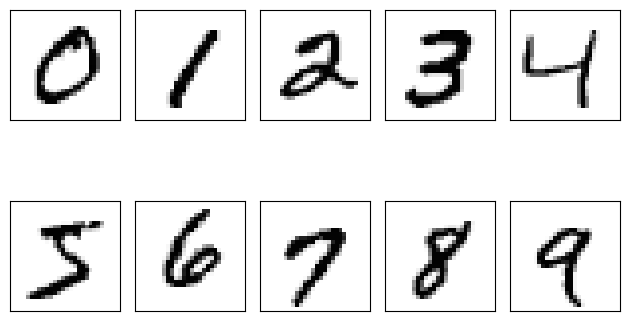

In [3]:
fig, ax = plt.subplots(2, 5, sharex=True, sharey=True)
ax = ax.flatten()
for ii in range(10):
    example_img = X[y == ii][0].reshape([28, 28])
    ax[ii].imshow(example_img, cmap='Greys')
    ax[ii].set(xticks=[], yticks=[])
plt.tight_layout()

To visualize the distribution of possible inputs, let's use PCA

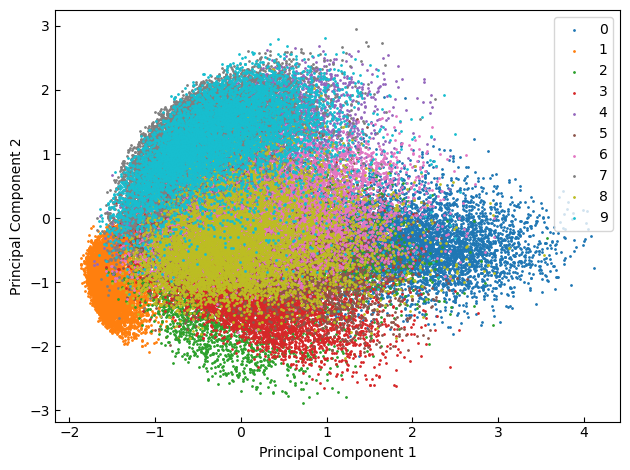

In [4]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, whiten=True)

X_pca = pca.fit_transform(X)

ax = plt.figure().gca()
for ii in range(10):
    mask = y == ii
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=1, label=ii)
ax.set(xlabel='Principal Component 1', ylabel='Principal Component 2')
ax.legend()
plt.tight_layout()

To prepare for our deep learning expedition, let's get a training, validation, and test set

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

def normalize(X):
    """ X is a uint8 that takes values from 0 to 255.
        Convert it to a float between -1 and 1
    """
    return 2. * X / 255. - 1.

label_encoder = OneHotEncoder(sparse_output=False) # Sparse output makes downstream work a bit annoying
y_enc = label_encoder.fit_transform(y[:, None])

X_train, X_test, y_train, y_test = train_test_split(normalize(X), y_enc, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print(f"The training set has size {X_train.shape}, {y_train.shape}")
print(f"The validation set has size {X_val.shape}, {y_val.shape}")
print(f"The testing set has size {X_test.shape}, {y_test.shape}")

The training set has size (44800, 784), (44800, 10)
The validation set has size (11200, 784), (11200, 10)
The testing set has size (14000, 784), (14000, 10)


Finally, let's establish a baseline. We are going to use mean-squared error loss here
\begin{align}
    \mathcal{L} = \sum_{i=1}^N (y_{\text{pred}} - y_{\text{true}})^2
\end{align}
PS1 will cover cross entropy loss.

In [6]:
def mse_loss(y_true, y_pred):
    return np.mean(
        np.power(y_true - y_pred, 2).sum(axis=1)
    )

def accuracy(y_true, y_pred):
    y_label = np.argmax(y_true, axis=1)
    pred_label = np.argmax(y_pred, axis=1)
    return np.mean(y_label == pred_label)

Logistic regression is as good a place as any to start. But this time we'll use the `sklearn` implementation rather than our own. This uses a 2nd order L-BFGS solver which should *in principle* do a bit better than gradient descent. 

In [7]:
from sklearn.linear_model import LogisticRegression

# Initialize and fit the model
lr_model = LogisticRegression(max_iter=10)
lr_model.fit(X_train, label_encoder.inverse_transform(y_train)[:, 0])

# Measure the training set performance
y_train_pred = lr_model.predict_proba(X_train)
train_mse = mse_loss(y_train, y_train_pred)
train_acc = accuracy(y_train, y_train_pred)
print(f"Train MSE = {train_mse:.3f}\tTrain Accuracy = {train_acc:.3f}")

# Measure the testing set performance
y_test_pred = lr_model.predict_proba(X_test)
test_mse = mse_loss(y_test, y_test_pred)
test_acc = accuracy(y_test, y_test_pred)
print(f"Test MSE = {test_mse:.3f}\tTest Accuracy = {test_acc:.3f}")

/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Train MSE = 0.226	Train Accuracy = 0.844
Test MSE = 0.223	Test Accuracy = 0.847


### Helper functions

In [8]:
import numpy as np

def preactivation(x, w, b):
    """ Applies weights and biases
    """
    return np.dot(x, w) + b

def grad_preactivation(x, w, b, z):
    """ Accepts inputs x, w, b, output z
        Returns gradient of output w.r.t. each input
    """
    dz_dx = w
    dz_dw = x
    dz_db = 1.
    return dz_dx, dz_dw, dz_db

def sigmoid(z):
    """ Squashing activation function
    """
    return 1. / (1. + np.exp(-np.clip(z, -250, 250)))

def grad_sigmoid(z, a):
    """ Accepts input z, output a
        Returns gradient of output w.r.t. input
    """ 
    return a * (1. - a)

def relu(z):
    """ Thresholded ramp activation function
    """
    return np.maximum(0, z)

def grad_relu(z, a):
    """ Accepts input z, output a
        Returns gradient of output w.r.t. input
    """
    return np.where(z >= 0, 1., 0.)

def mse_loss(y_true, y_pred):
    """ Mean squared error 
    """
    return np.mean(
        np.power(y_true - y_pred, 2).sum(axis=1)
    )

def grad_mse_loss(y_true, y_pred):
    """ Returns gradient of MSE loss w.r.t. model prediction y_pred
    """
    return 2. / y_true.shape[0] * (y_pred - y_true)

## N-layer MLP

It would be nice to have a framework to build arbitrarily deep multi-layer perceptrons without having to type so much, right? There is a compositional structure to these, so we should be able to loop some of the computation. For example, each layer generally computes
\begin{align}
    z^{(\ell)}_i &= \sum_{j=1}^{N_i^{(\ell)}} a^{(\ell)}_j w^{(\ell)}_{ji} + b^{(\ell)}_i & & i = 1, \dots, N^{(\ell)}_o\\
    a^{(\ell)}_i &= f^{(\ell)}(z^{(\ell)}_i) & & i = 1, \dots, N^{(\ell)}_o\\
\end{align}

In [9]:
class MLP_Layer:
    """ To reduce redundancy, we're going to implement a standalone MLP layer. 
        This will implement:
            1. forward function that computes a preactivation and an activation
            2. backward function that computes gradients w.r.t. each parameter
            3. weight_update function that updates weight values using a particular learning rate
    """
    def __init__(self, 
                 num_inputs, 
                 num_outputs,
                 activation,
                 grad_activation):
        
        self.num_inputs = num_inputs
        self.num_outputs = num_outputs
        self.activation = activation
        self.grad_activation = grad_activation

        self.w_ = np.random.normal(
            loc=0,
            scale=2. / self.num_inputs, # He initialization
            size=(self.num_inputs, self.num_outputs)
        )
        self.b_ = np.zeros(self.num_outputs)

    def preactivation(self, x):
        z = np.dot(x, self.w_) + self.b_
        return z
    
    def grad_preactivation(self, x, z):
        dz_dx = self.w_
        dz_dw = x
        dz_db = 1.
        return dz_dx, dz_dw, dz_db

    def forward(self, x):
        z = self.preactivation(x)
        a = self.activation(z)
        return a, z

    def backward(self, a, z, x, d_loss__d_a):
        """ d_loss__d_a is the gradient w.r.t. the output of this layer
            It is computed upstream and passed here via backpropagation.
        """
        # Compute gradient w.r.t. preactivation
        d_a__d_z = self.grad_activation(z, a)
        d_loss__d_z = d_loss__d_a * d_a__d_z

        # Compute gradient w.r.t. input, weight, bias
        d_z__d_x, d_z__d_w, d_z__d_b = self.grad_preactivation(x, z)

        d_loss__d_x = np.einsum('Bo,io->Bi', d_loss__d_z, d_z__d_x)
        d_loss__d_w = np.einsum('Bo,Bi->io', d_loss__d_z, d_z__d_w)
        d_loss__d_b = np.einsum('Bo,->o', d_loss__d_z, d_z__d_b)
        
        return d_loss__d_x, d_loss__d_w, d_loss__d_b
        
    def weight_update(self, grad_w, grad_b, lr):
        self.w_ -= lr * grad_w
        self.b_ -= lr * grad_b

In [10]:
class MLP_NLayer:
    """ More general N-layer architecture
    """
    def __init__(self, 
                 num_inputs,
                 num_hidden,
                 num_hidden_layers,
                 num_outputs,
                 random_seed=42):
        self.num_inputs = num_inputs
        self.num_hidden = num_hidden
        self.num_hidden_layers = num_hidden_layers
        self.num_outputs = num_outputs
        self.random_seed = random_seed

        self._initialize_weights()

    def _initialize_weights(self):
        np.random.seed(self.random_seed)

        self.layers = []
        # Initialize hidden layers with ReLU activations
        for ii in range(self.num_hidden_layers):
            self.layers.append(
                MLP_Layer(
                    num_inputs=self.num_inputs if ii == 0 else self.num_hidden,
                    num_outputs=self.num_hidden,
                    activation=relu,
                    grad_activation=grad_relu,
                )
            )

        # Initialize output layer with sigmoid activation
        self.layers.append(
            MLP_Layer(
                num_inputs=self.num_hidden if self.num_hidden_layers > 0 else self.num_inputs,
                num_outputs=self.num_outputs,
                activation=sigmoid,
                grad_activation=grad_sigmoid
            )
        )

    def forward(self, x):
        """ Feed input data x through each network layer 
            Return a final network output, as well as the intermediate
            values at each layer
        """
        # Apply hidden layer functions in order
        # Store preactivations and activations in a list called layer_values
        layer_values = [x,]
        for layer in self.layers:
            a, z = layer.forward(x)
            layer_values.extend([z, a]) # Add preactivation, activation to layer_values
            x = a # Layer output becomes next layer input
            
        return x, layer_values

    def backward(self, x, y_true, *layer_values):
        """ Compute gradients with respect to each model parameter """
        B, I = x.shape # [B, I]
        _, O = y_true.shape # [B, O]
        assert y_true.shape[0] == B

        # Iterate through layers backward
        layers = self.layers[::-1]

        # Start by computing gradient of loss w.r.t. final layer output
        d_loss__d_a = grad_mse_loss(y_true, layer_values[-1])

        # At each step, I need to pass the layer input, preactivation, 
        # and output to the gradient function
        # layer_values is [x, z1, a1, z2, a2, ..., zl, al ,zo, ao]
        values = layer_values[::-1] # [ao, zo, al, zl, ..., a2, z2, a1, z1, x]
        outputs = values[::2] # [ao, al, ..., a2, a1]
        preacts = values[1::2] # [zo, zl, ..., z2, z1]
        inputs =  values[2::2] # [al, ..., a1, x]

        gradients = []
        for layer, x, z, a in zip(layers, inputs, preacts, outputs):
            # Do the computation in each layer
            d_loss__d_x, d_loss__d_w, d_loss__d_b = \
                layer.backward(a, z, x, d_loss__d_a)

            # Store the gradients for weight,bias update
            gradients.append((d_loss__d_w, d_loss__d_b))

            # Propagate the gradient to the next layer
            d_loss__d_a = d_loss__d_x
            
        # We're done. Return all the gradients w.r.t. weights and biases
        # Reverse them to be sure that they match the order of layers
        return reversed(gradients)

    def weight_update(self, *gradients, lr=0.3):
        """ Update weights and biases via gradient descent
        """
        for layer, (grad_w, grad_b) in zip(self.layers, gradients):
            layer.weight_update(grad_w, grad_b, lr)

## Training the model

In [11]:
def batch_loader(X, y, batch_size=32):
    """ Iterator that produces batches of a particular size """
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)

    for start in range(0, indices.shape[0] - batch_size + 1, batch_size):
        batch_idx = indices[start:start+batch_size]
        yield X[batch_idx], y[batch_idx]

loader = batch_loader(X_train, y_train, batch_size=32)
Xb, yb = next(loader)
print(Xb.shape, yb.shape)

(32, 784) (32, 10)


In [12]:
from tqdm.auto import tqdm, trange

def train(model,
          X_train,
          y_train,
          X_val,
          y_val,
          num_epochs=10,
          lr=0.3,
          lr_decay=1.,
          batch_size=128):
    """ Standalone function to execute the mini-batch SGD training loop

        Parameters:
        -----------
        X_train, y_train: Training dataset
        X_val, y_val: Validation dataset
        num_epochs: number of passes through the dataset, use 10 for consistent comparison with LR above
        batch_size: number of samples in each minibatch
        lr: learning rate for gradient updates
        lr_decay: decreases the learning rate, may aid SGD convergence
    """
    train_mse, train_acc = [], []
    val_mse, val_acc = [], []

    pbar_epoch = trange(num_epochs)
    for ii in pbar_epoch:        
        loader = batch_loader(X_train, y_train, batch_size=batch_size)
        for Xb, yb in tqdm(loader, position=1, leave=False, total=X_train.shape[0] // batch_size):
            # Make the prediction
            y_pred, layer_values = model.forward(Xb)
            # Compute the gradients
            gradients = model.backward(Xb, yb, *layer_values)

            # Update the weights
            model.weight_update(*gradients, lr=lr)

        # Compute loss, accuracy on training set
        y_train_pred, _ = model.forward(X_train)
        train_mse.append(mse_loss(y_train, y_train_pred))
        train_acc.append(accuracy(y_train, y_train_pred))

        # Compute loss, accuracy on validation set
        y_val_pred, _ = model.forward(X_val)
        val_mse.append(mse_loss(y_val, y_val_pred))
        val_acc.append(accuracy(y_val, y_val_pred))

        pbar_epoch.set_postfix(
            epoch=f"{ii+1:03d} / {num_epochs:03d}",
            train_mse=f"{train_mse[-1]:.3f}",
            train_acc=f"{train_acc[-1]:.3f}",
            val_mse=f"{val_mse[-1]:.3f}",
            val_acc=f"{val_acc[-1]:.3f}")

        lr *= lr_decay # This aids SGD convergence by lowering the step size over time

    return train_mse, train_acc, val_mse, val_acc

In [13]:
model = MLP_NLayer(num_inputs=X_train.shape[1], 
                   num_hidden=32, 
                   num_hidden_layers=3,
                   num_outputs=y_train.shape[1])
train_mse, train_acc, val_mse, val_acc = train(model, X_train, y_train, X_val, y_val)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/350 [00:00<?, ?it/s]

  0%|          | 0/350 [00:00<?, ?it/s]

  0%|          | 0/350 [00:00<?, ?it/s]

  0%|          | 0/350 [00:00<?, ?it/s]

...

  0%|          | 0/350 [00:00<?, ?it/s]

  0%|          | 0/350 [00:00<?, ?it/s]

  0%|          | 0/350 [00:00<?, ?it/s]

  0%|          | 0/350 [00:00<?, ?it/s]

  0%|          | 0/350 [00:00<?, ?it/s]

In [14]:
# Make predictions on the test set here
y_test_pred, _ = model.forward(X_test)
test_mse = mse_loss(y_test, y_test_pred)
test_acc = accuracy(y_test, y_test_pred)
print(f"Test MSE = {test_mse:.3f}\tTest Accuracy = {test_acc:.3f}")

Test MSE = 0.091	Test Accuracy = 0.943
